<!-- NINO26-CABECALHO v1 -->
# 3E — Sensibilidade temporal sem breakpoint pré-fixado

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3E`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Quantifica quanto os achados dependem de eventos individuais e da autocorrelação, sem impor regimes artificiais — a defesa contra conclusões dominadas por poucos eventos.

## Pergunta
Quanto as correlações que sobreviveram ao 3D dependem de eventos ENSO individuais e da estrutura autocorrelacionada?

## Desafio (hipótese a testar)
A unidade de incerteza deve ser o evento, não a semana; nenhum corte temporal fixo (ex.: 1993/2010) pode entrar como filtro.

## Metodologia (com referências)
Bootstrap em blocos e leave-one-event-out, com envelope de IC e fração de mesmo sinal (validação para dados dependentes — Roberts et al., 2017; Wilks, 2016).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3E01", fase=3, bloco="E",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3E_sensibilidade_temporal.ipynb",
                 fontes={"<tabela>": df})   # -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3E01` | `Fig_3E01.png` | `Fig_3E01/` | sensibilidade bootstrap/LOO |
| `Fig_3E02` | `Fig_3E02.png` | `Fig_3E02/` | influência de cada evento (LOO) |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; validação por `python scripts/validar_figuras.py --strict`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.temporal_stability import (
    leave_one_event_out_correlation, moving_block_bootstrap_correlation,
    summarize_correlation_stability,
)

w = pd.read_csv(u.FEAT/'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
w = w.loc['1993-01-01':].copy()
best = pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')

# Eventos EN e LN definem apenas os intervalos retirados no LOO; nao sao regimes.
events_path = u.STATS/'phase3_events_en_ln.csv'
if events_path.exists():
    events = pd.read_csv(events_path, parse_dates=['onset','fim'])
else:
    events = u.events_noaa().rename(columns={'event_start':'onset','event_end':'fim'})
    events['tipo'] = 'el_nino'
event_labels = pd.Series(pd.NA, index=w.index, dtype='object')
for _, event in events.iterrows():
    event_labels.loc[pd.to_datetime(event['onset']):pd.to_datetime(event['fim'])] = event['event_id']

BLOCK_LENGTHS = (26, 52, 78)
N_BOOT = 1000
block_rows, loo_frames, boot_frames = [], [], []
for iv, (variavel, row) in enumerate(best.iterrows()):
    lag = int(row['lag_semanas'])
    x = w[variavel].shift(lag)
    y = w['nino34_ssta']
    loo = leave_one_event_out_correlation(x, y, event_labels, min_samples=80)
    loo.insert(0, 'lag_semanas', lag)
    loo.insert(0, 'variavel', variavel)
    loo_frames.append(loo)
    for block_length in BLOCK_LENGTHS:
        boot = moving_block_bootstrap_correlation(
            x, y, block_length=block_length, n_boot=N_BOOT,
            random_state=3100 + 100*iv + block_length,
        )
        metrics = summarize_correlation_stability(boot, loo)
        metrics.update({'variavel': variavel, 'lag_semanas': lag, 'papel': 'sensibilidade; nao gate'})
        block_rows.append(metrics)
        boot_frames.append(pd.DataFrame({
            'variavel': variavel, 'lag_semanas': lag,
            'bloco_semanas': block_length,
            'replica': np.arange(1, len(boot.bootstrap_r)+1),
            'r_bootstrap': boot.bootstrap_r,
        }))

by_block = pd.DataFrame(block_rows)
loo_all = pd.concat(loo_frames, ignore_index=True)
boot_all = pd.concat(boot_frames, ignore_index=True)
summary_rows = []
for variavel, group in by_block.groupby('variavel', sort=False):
    loo_v = loo_all.query('variavel == @variavel').dropna(subset=['r_sem_evento']).copy()
    r_full = float(group['r_full'].iloc[0])
    if len(loo_v):
        delta = (loo_v['r_sem_evento'] - r_full).abs()
        maior = loo_v.loc[delta.idxmax(), 'evento_removido']
        max_delta = float(delta.max())
    else:
        maior, max_delta = '', np.nan
    summary_rows.append({
        'variavel': variavel, 'lag_semanas': int(group['lag_semanas'].iloc[0]), 'r_full': r_full,
        'bootstrap_ic95_inf_envelope': float(group['bootstrap_ic95_inf'].min()),
        'bootstrap_ic95_sup_envelope': float(group['bootstrap_ic95_sup'].max()),
        'bootstrap_min_fracao_mesmo_sinal': float(group['bootstrap_fracao_mesmo_sinal'].min()),
        'bootstrap_blocos_semanas': '26|52|78',
        'loo_eventos_n': int(group['loo_eventos_n'].iloc[0]),
        'loo_eventos_r_min': float(group['loo_eventos_r_min'].iloc[0]),
        'loo_eventos_r_max': float(group['loo_eventos_r_max'].iloc[0]),
        'loo_eventos_fracao_mesmo_sinal': float(group['loo_eventos_fracao_mesmo_sinal'].iloc[0]),
        'loo_evento_maior_influencia': maior, 'loo_max_delta_r': max_delta,
        'papel_3E': 'sensibilidade; nao filtro e nao breakpoint',
    })
summary = pd.DataFrame(summary_rows).set_index('variavel')
u.save_table(summary, 'phase3E_sensibilidade_resumo.csv')
u.save_table(summary, 'phase3E_estabilidade.csv')  # alias historico; sem corte 2010
u.save_table(by_block, 'phase3E_bootstrap_blocos.csv', index=False)
u.save_table(boot_all, 'phase3E_bootstrap_correlacoes.csv', index=False)
u.save_table(loo_all, 'phase3E_leave_one_event_out.csv', index=False)
print(summary.round(3).to_string())


[tabela] data\processed\parquet\statistics\phase3E_sensibilidade_resumo.csv
[tabela] data\processed\parquet\statistics\phase3E_estabilidade.csv
[tabela] data\processed\parquet\statistics\phase3E_bootstrap_blocos.csv
[tabela] data\processed\parquet\statistics\phase3E_bootstrap_correlacoes.csv
[tabela] data\processed\parquet\statistics\phase3E_leave_one_event_out.csv
                      lag_semanas  r_full  bootstrap_ic95_inf_envelope  bootstrap_ic95_sup_envelope  bootstrap_min_fracao_mesmo_sinal bootstrap_blocos_semanas  loo_eventos_n  loo_eventos_r_min  loo_eventos_r_max  loo_eventos_fracao_mesmo_sinal loo_evento_maior_influencia  loo_max_delta_r                                    papel_3E
variavel                                                                                                                                                                                                                                                                                                   

[figura] data\processed\figures\fase3\Fig_3E1_sensibilidade_bootstrap_loo.png


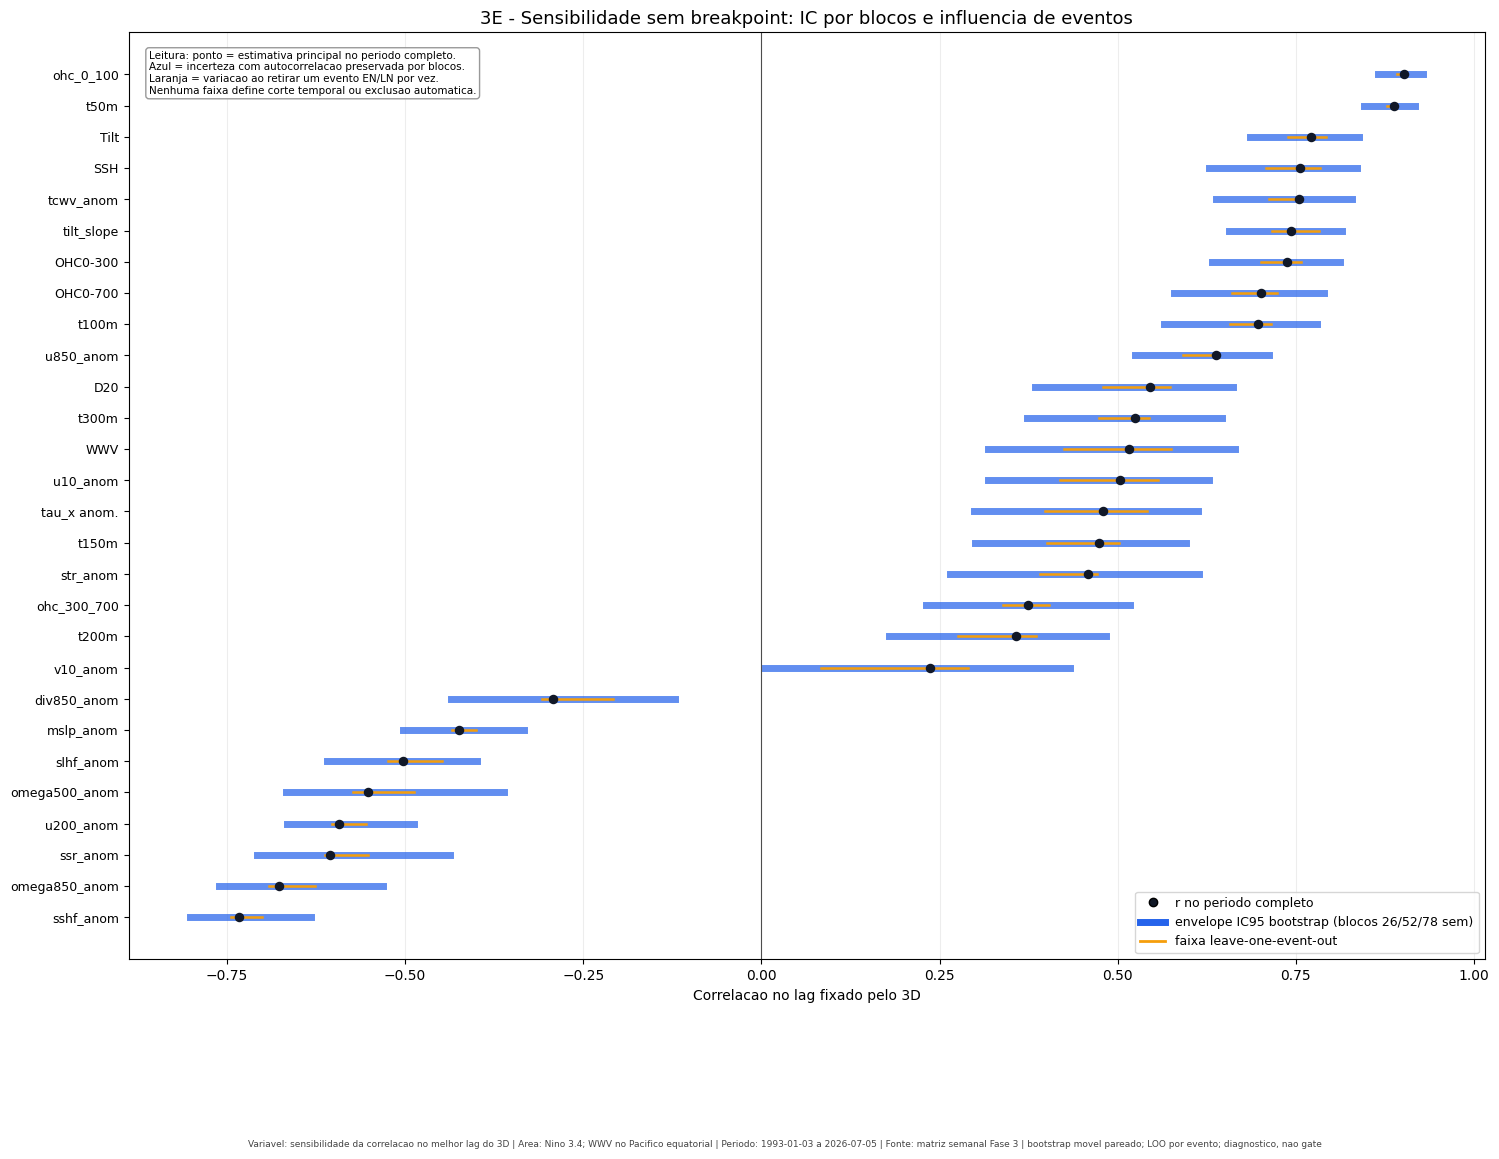

In [2]:
from matplotlib.lines import Line2D
plot = summary.sort_values('r_full')
ypos = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(17.5, max(10, 0.43*len(plot))))
for yi, (_, row) in zip(ypos, plot.iterrows()):
    ax.plot([row['bootstrap_ic95_inf_envelope'], row['bootstrap_ic95_sup_envelope']], [yi, yi], color='#2563eb', lw=5, alpha=.72)
    ax.plot([row['loo_eventos_r_min'], row['loo_eventos_r_max']], [yi, yi], color='#f59e0b', lw=1.8)
    ax.scatter(row['r_full'], yi, s=34, color='#111827', zorder=3)
ax.axvline(0, color='0.3', lw=.8)
ax.set_yticks(ypos)
ax.set_yticklabels([u.var_label(v, short=True) for v in plot.index], fontsize=9)
ax.set_xlabel('Correlacao no lag fixado pelo 3D')
ax.set_title('3E - Sensibilidade sem breakpoint: IC por blocos e influencia de eventos', fontsize=13)
ax.grid(axis='x', alpha=.22)
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='none', markerfacecolor='#111827', label='r no periodo completo'),
    Line2D([0],[0], color='#2563eb', lw=5, label='envelope IC95 bootstrap (blocos 26/52/78 sem)'),
    Line2D([0],[0], color='#f59e0b', lw=2, label='faixa leave-one-event-out'),
], loc='lower right', fontsize=9)
u.add_note(ax, 'Leitura: ponto = estimativa principal no periodo completo.\nAzul = incerteza com autocorrelacao preservada por blocos.\nLaranja = variacao ao retirar um evento EN/LN por vez.\nNenhuma faixa define corte temporal ou exclusao automatica.', loc='upper left')
u.stamp_caption(fig, variavel='sensibilidade da correlacao no melhor lag do 3D', area='Nino 3.4; WWV no Pacifico equatorial', periodo=f"{w.index.min().date()} a {w.index.max().date()}", fonte='matriz semanal Fase 3', extra='bootstrap movel pareado; LOO por evento; diagnostico, nao gate')
u.save_fig(fig, 'Fig_3E1_sensibilidade_bootstrap_loo.png')
plt.show()


[figura] data\processed\figures\fase3\Fig_3E2_influencia_eventos_loo.png


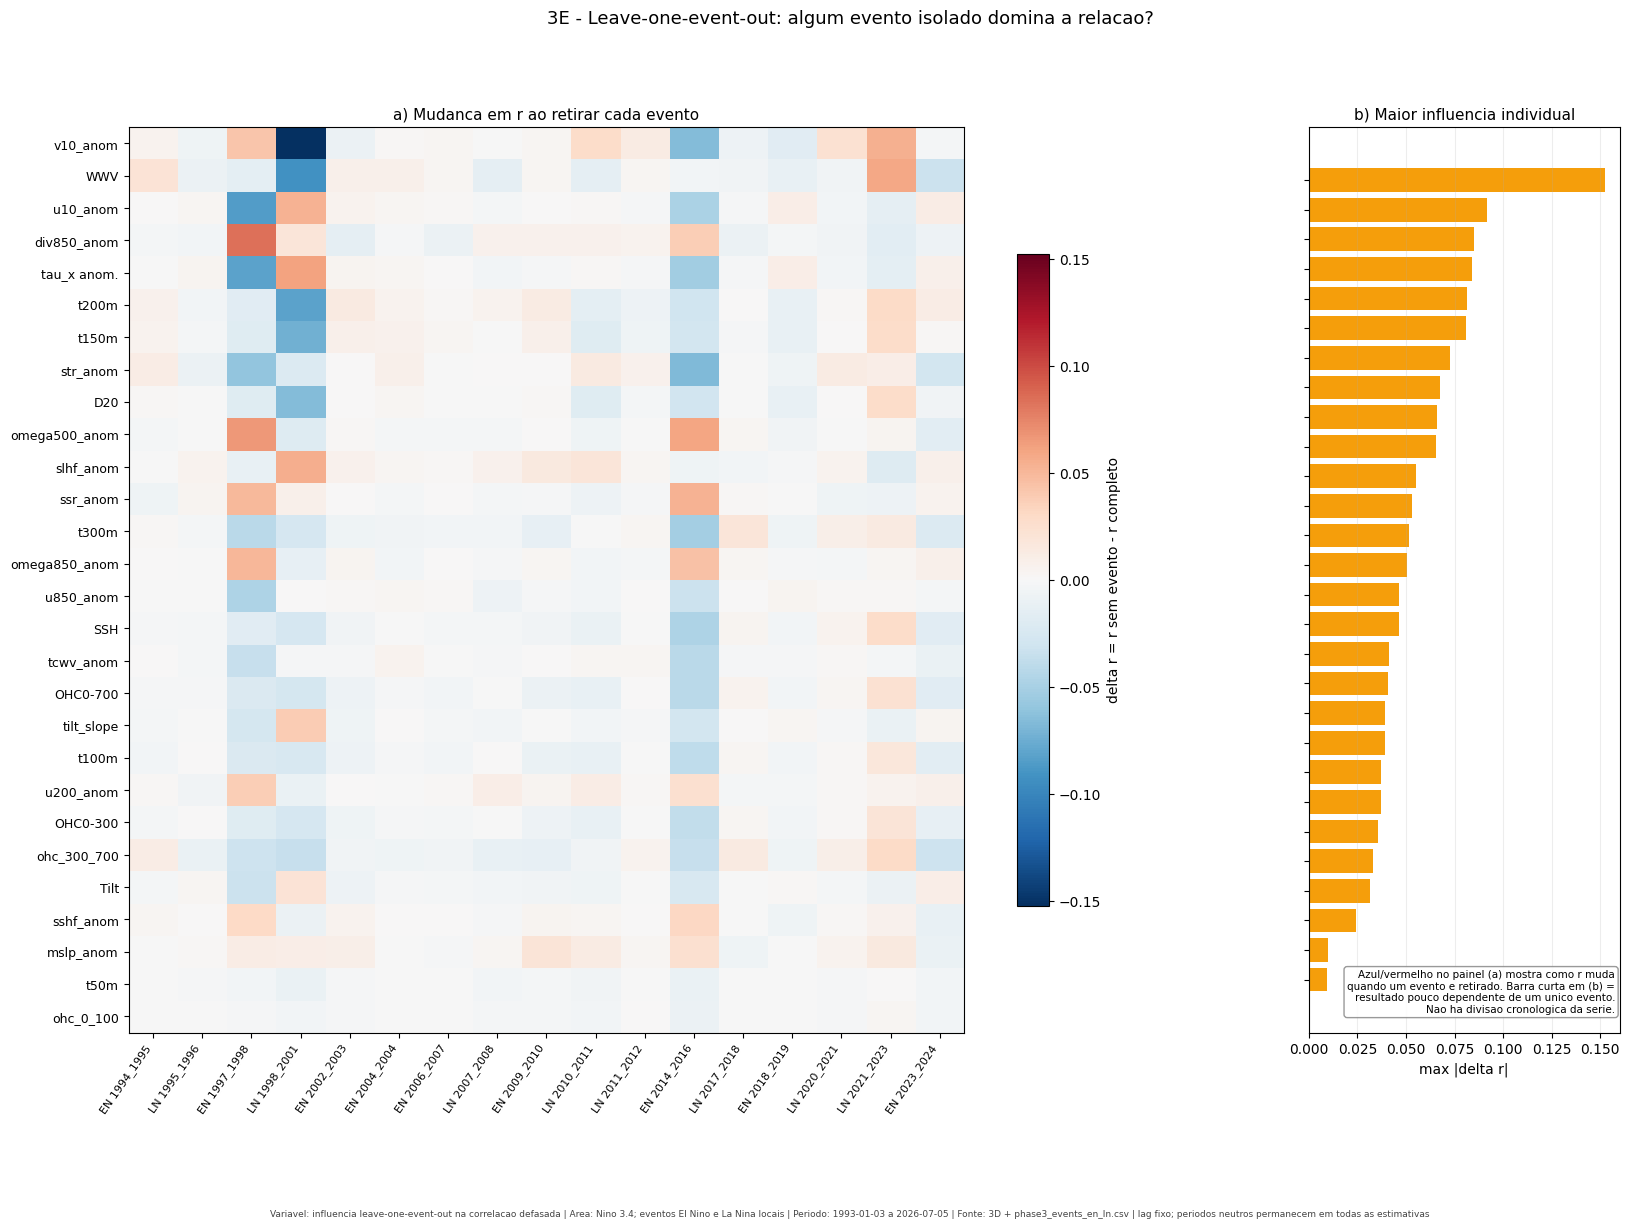

In [3]:
loo_plot = loo_all.merge(summary[['r_full']], left_on='variavel', right_index=True, how='left')
loo_plot['delta_r'] = loo_plot['r_sem_evento'] - loo_plot['r_full']
event_order = [e for e in events.sort_values('onset')['event_id'] if e in set(loo_plot['evento_removido'])]
var_order = summary.sort_values('loo_max_delta_r', ascending=False).index.tolist()
piv = loo_plot.pivot(index='variavel', columns='evento_removido', values='delta_r').reindex(index=var_order, columns=event_order)
vmax = max(float(np.nanmax(np.abs(piv.values))), 0.05)
fig, (ax, ax_bar) = plt.subplots(1, 2, figsize=(max(18, 0.72*len(event_order)+7), max(10, 0.42*len(var_order))), gridspec_kw={'width_ratios':[4.2,1.25]})
im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(event_order)))
ax.set_xticklabels([e.replace('el_nino_','EN ').replace('la_nina_','LN ') for e in event_order], rotation=55, ha='right', fontsize=8)
ax.set_yticks(range(len(var_order)))
ax.set_yticklabels([u.var_label(v, short=True) for v in var_order], fontsize=9)
ax.set_title('a) Mudanca em r ao retirar cada evento', fontsize=11)
fig.colorbar(im, ax=ax, shrink=.72, label='delta r = r sem evento - r completo')
impact = summary.reindex(var_order)['loo_max_delta_r']
ax_bar.barh(np.arange(len(var_order)), impact, color='#f59e0b')
ax_bar.set_yticks(np.arange(len(var_order))); ax_bar.set_yticklabels([]); ax_bar.invert_yaxis()
ax_bar.set_xlabel('max |delta r|')
ax_bar.set_title('b) Maior influencia individual', fontsize=11)
ax_bar.grid(axis='x', alpha=.22)
fig.suptitle('3E - Leave-one-event-out: algum evento isolado domina a relacao?', fontsize=13)
u.add_note(ax_bar, 'Azul/vermelho no painel (a) mostra como r muda\nquando um evento e retirado. Barra curta em (b) =\nresultado pouco dependente de um unico evento.\nNao ha divisao cronologica da serie.', loc='lower right')
u.stamp_caption(fig, variavel='influencia leave-one-event-out na correlacao defasada', area='Nino 3.4; eventos El Nino e La Nina locais', periodo=f"{w.index.min().date()} a {w.index.max().date()}", fonte='3D + phase3_events_en_ln.csv', extra='lag fixo; periodos neutros permanecem em todas as estimativas')
u.save_fig(fig, 'Fig_3E2_influencia_eventos_loo.png')
plt.show()


**Leitura do 3E.** O resultado principal continua sendo a correlacao de periodo completo que passou pelo rigor do 3D. O envelope bootstrap informa quanto a incerteza muda quando a dependencia serial e preservada em blocos; o leave-one-event-out mostra se um El Nino ou La Nina isolado domina o valor. Essas sao analises de sensibilidade, nao evidencias de dois regimes e nao filtros binarios.

**Decisao sobre WWV.** WWV permanece disponivel como um dos indicadores fisicos de recarga. Como ele e calculado a partir de D20 integrado em area, sua informacao se sobrepoe a D20, OHC, SSH e tilt. A escolha de representante do bloco deve vir da pergunta fisica, da reducao de colinearidade/PCA e da validacao, nunca de um privilegio fixo de WWV nem da antiga divisao 1993-2009/2010+.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Roberts, D. R., et al. (2017). Cross-validation strategies for data with temporal/spatial/hierarchical structure. *Ecography*, 40, 913-929. https://doi.org/10.1111/ecog.02881
2. Wilks, D. S. (2016). 'The Stippling Shows Statistically Significant Grid Points'. *BAMS*, 97, 2263-2273. https://doi.org/10.1175/BAMS-D-15-00267.1

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.